In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
base_path = "/content/drive/MyDrive/AI-Powered Hospitality Revenue Optimization/Dataset/"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(base_path + "hotel_bookings_cleaned.csv")

In [5]:
daily_demand = (
    df.groupby(["arrival_date", "hotel"])
      .size()
      .reset_index(name="demand")
)

daily_demand.head()

,arrival_date,hotel,demand
0,2015-07-01,City Hotel,12
1,2015-07-01,Resort Hotel,41
2,2015-07-02,City Hotel,11
3,2015-07-02,Resort Hotel,43
4,2015-07-03,City Hotel,11


In [6]:
print("Start:", daily_demand["arrival_date"].min())
print("End:", daily_demand["arrival_date"].max())

Start: 2015-07-01
End: 2017-08-31


In [7]:
city = daily_demand[
    daily_demand["hotel"] == "City Hotel"
].copy()

resort = daily_demand[
    daily_demand["hotel"] == "Resort Hotel"
].copy()

In [8]:
city = city.set_index("arrival_date")["demand"]

resort = resort.set_index("arrival_date")["demand"]

In [9]:
print("City Hotel:")
print(city.head())

print("\nResort Hotel:")
print(resort.head())

City Hotel:
arrival_date
2015-07-01    12
2015-07-02    11
2015-07-03    11
2015-07-04    10
2015-07-05     8
Name: demand, dtype: int64

Resort Hotel:
arrival_date
2015-07-01    41
2015-07-02    43
2015-07-03    40
2015-07-04    50
2015-07-05    44
Name: demand, dtype: int64


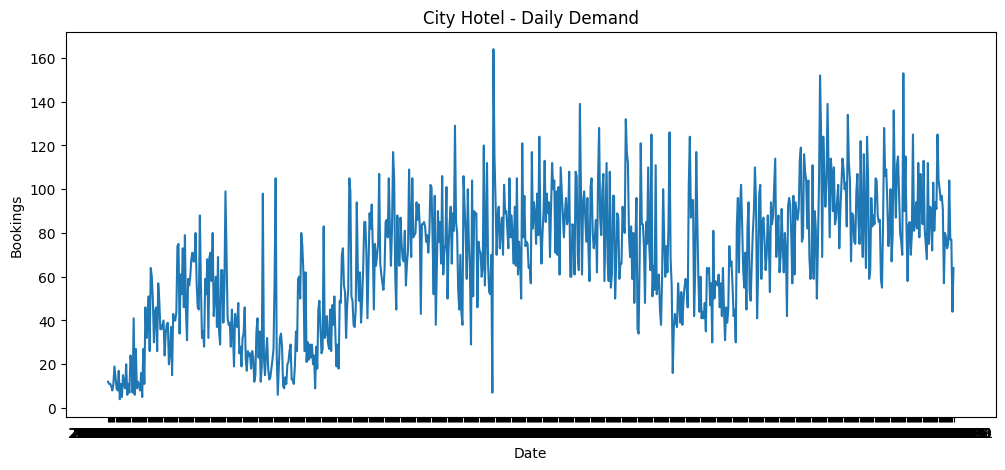

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(city)

plt.title("City Hotel - Daily Demand")
plt.xlabel("Date")
plt.ylabel("Bookings")

plt.show()

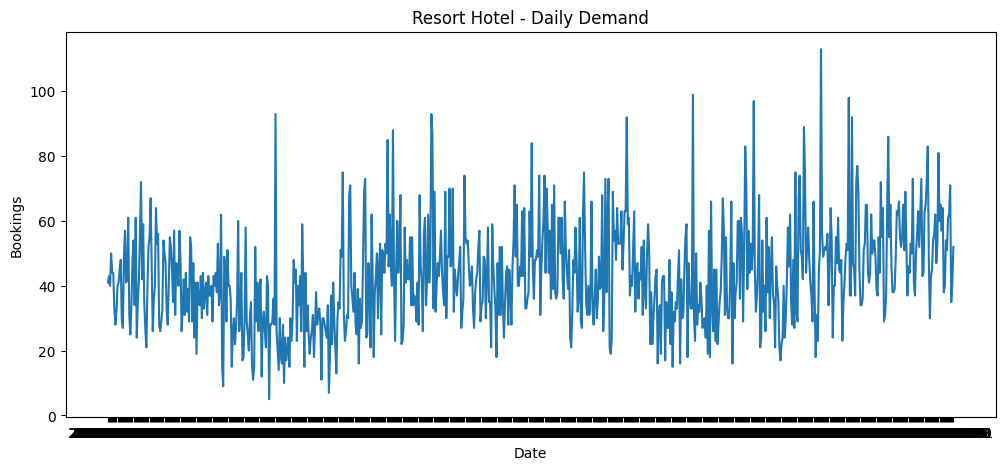

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(resort)

plt.title("Resort Hotel - Daily Demand")
plt.xlabel("Date")
plt.ylabel("Bookings")

plt.show()

In [12]:
city_train = city.iloc[:int(len(city) * 0.8)]
city_test = city.iloc[int(len(city) * 0.8):]

resort_train = resort.iloc[:int(len(resort) * 0.8)]
resort_test = resort.iloc[int(len(resort) * 0.8):]

print("City Hotel")
print("Train:", len(city_train))
print("Test:", len(city_test))

print("\nResort Hotel")
print("Train:", len(resort_train))
print("Test:", len(resort_test))

City Hotel
Train: 634
Test: 159

Resort Hotel
Train: 634
Test: 159


In [13]:
print("City train:", city_train.index.min(), "to", city_train.index.max())
print("City test:", city_test.index.min(), "to", city_test.index.max())

print("\nResort train:", resort_train.index.min(), "to", resort_train.index.max())
print("Resort test:", resort_test.index.min(), "to", resort_test.index.max())

City train: 2015-07-01 to 2017-03-25
City test: 2017-03-26 to 2017-08-31

Resort train: 2015-07-01 to 2017-03-25
Resort test: 2017-03-26 to 2017-08-31


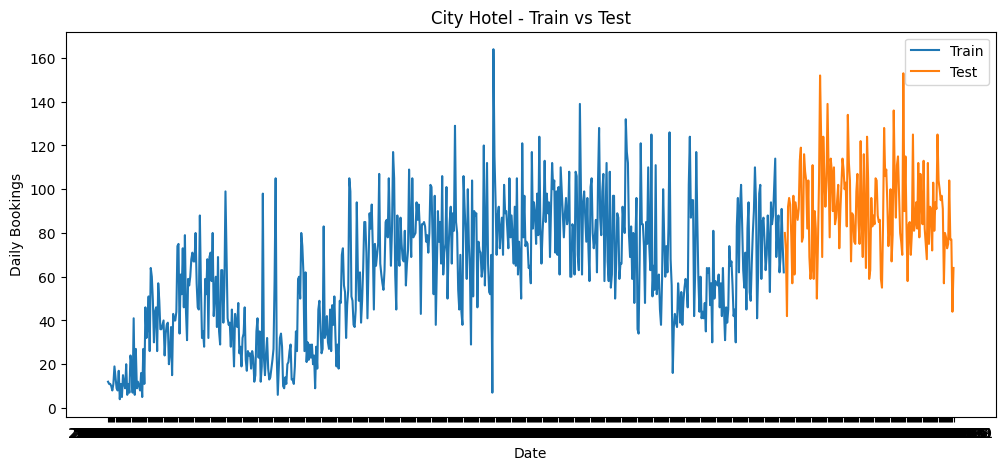

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(city_train, label="Train")
plt.plot(city_test, label="Test")

plt.title("City Hotel - Train vs Test")
plt.xlabel("Date")
plt.ylabel("Daily Bookings")
plt.legend()

plt.show()

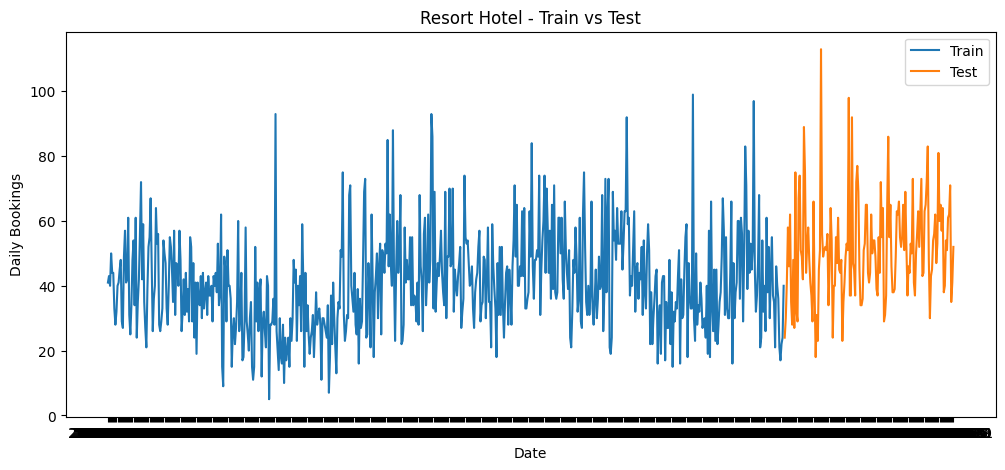

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(resort_train, label="Train")
plt.plot(resort_test, label="Test")

plt.title("Resort Hotel - Train vs Test")
plt.xlabel("Date")
plt.ylabel("Daily Bookings")
plt.legend()

plt.show()

**7-Day Moving Average**

In [16]:
def moving_average_forecast(train, test, window=7):
    history = list(train)
    predictions = []

    for _ in range(len(test)):
        prediction = np.mean(history[-window:])
        predictions.append(prediction)
        history.append(test.iloc[len(predictions) - 1])

    return np.array(predictions)

In [17]:
city_ma = moving_average_forecast(city_train, city_test)
resort_ma = moving_average_forecast(resort_train, resort_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

city_mae = mean_absolute_error(city_test, city_ma)
city_rmse = np.sqrt(mean_squared_error(city_test, city_ma))

resort_mae = mean_absolute_error(resort_test, resort_ma)
resort_rmse = np.sqrt(mean_squared_error(resort_test, resort_ma))

print("City Hotel")
print("MAE:", round(city_mae, 2))
print("RMSE:", round(city_rmse, 2))

print("\nResort Hotel")
print("MAE:", round(resort_mae, 2))
print("RMSE:", round(resort_rmse, 2))

City Hotel
MAE: 16.47
RMSE: 20.84

Resort Hotel
MAE: 12.73
RMSE: 16.54


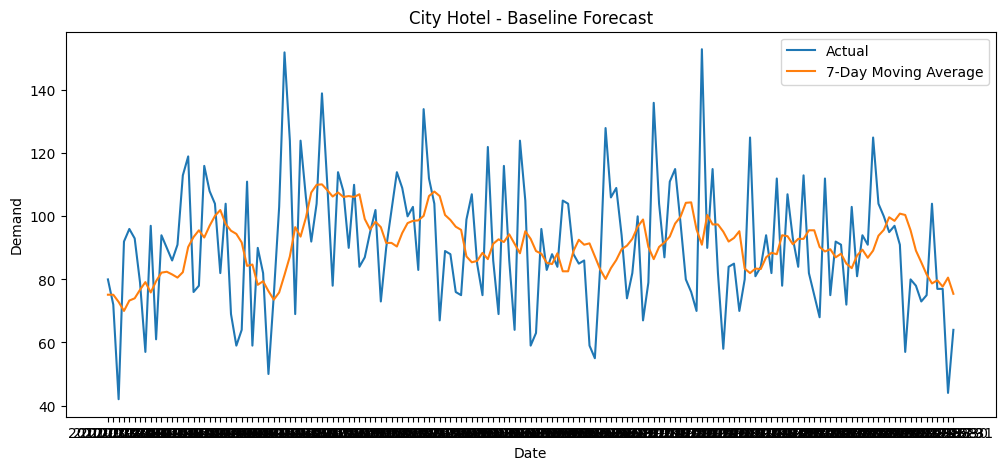

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(city_test.index, city_test.values, label="Actual")
plt.plot(city_test.index, city_ma, label="7-Day Moving Average")

plt.title("City Hotel - Baseline Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

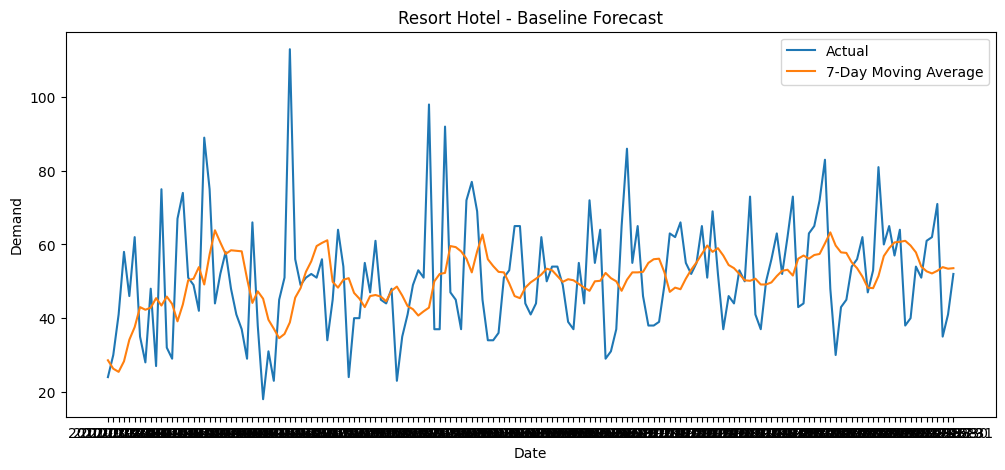

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(resort_test.index, resort_test.values, label="Actual")
plt.plot(resort_test.index, resort_ma, label="7-Day Moving Average")

plt.title("Resort Hotel - Baseline Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

**SARIMA**

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [22]:
city_model = SARIMAX(
    city_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

city_fit = city_model.fit(disp=False)

city_sarima = city_fit.forecast(steps=len(city_test))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [23]:
resort_model = SARIMAX(
    resort_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

resort_fit = resort_model.fit(disp=False)

resort_sarima = resort_fit.forecast(steps=len(resort_test))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [24]:
city_sarima_mae = mean_absolute_error(city_test, city_sarima)
city_sarima_rmse = np.sqrt(
    mean_squared_error(city_test, city_sarima)
)

resort_sarima_mae = mean_absolute_error(resort_test, resort_sarima)
resort_sarima_rmse = np.sqrt(
    mean_squared_error(resort_test, resort_sarima)
)

print("City Hotel")
print("MAE:", round(city_sarima_mae, 2))
print("RMSE:", round(city_sarima_rmse, 2))

print("\nResort Hotel")
print("MAE:", round(resort_sarima_mae, 2))
print("RMSE:", round(resort_sarima_rmse, 2))

City Hotel
MAE: 16.37
RMSE: 21.05

Resort Hotel
MAE: 17.65
RMSE: 21.74


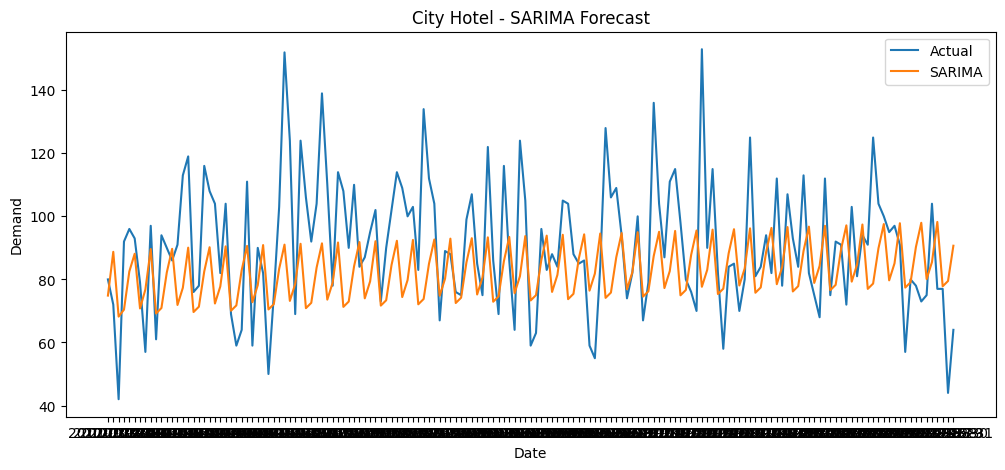

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(city_test.index, city_test, label="Actual")
plt.plot(city_test.index, city_sarima, label="SARIMA")

plt.title("City Hotel - SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

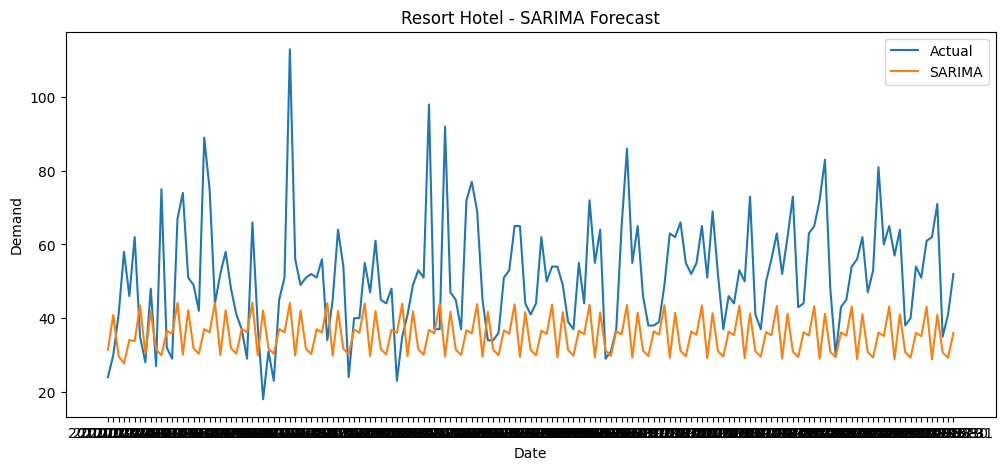

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(resort_test.index, resort_test, label="Actual")
plt.plot(resort_test.index, resort_sarima, label="SARIMA")

plt.title("Resort Hotel - SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

**Random Forest**

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [28]:
def create_features(series):
    data = pd.DataFrame({"demand": series})

    data["day_of_week"] = data.index.dayofweek
    data["month"] = data.index.month
    data["day_of_year"] = data.index.dayofyear

    data["lag_1"] = data["demand"].shift(1)
    data["lag_7"] = data["demand"].shift(7)

    data["rolling_7"] = data["demand"].shift(1).rolling(7).mean()

    return data.dropna()

In [29]:
city.index = pd.to_datetime(city.index)
city_features = create_features(city)

city_train_ml = city_features.loc[:city_train.index[-1]]
city_test_ml = city_features.loc[city_test.index[0]:]

X_train_city = city_train_ml.drop("demand", axis=1)
y_train_city = city_train_ml["demand"]

X_test_city = city_test_ml.drop("demand", axis=1)
y_test_city = city_test_ml["demand"]

In [30]:
rf_city = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_city.fit(X_train_city, y_train_city)

city_rf = rf_city.predict(X_test_city)

In [31]:
city_rf_mae = mean_absolute_error(y_test_city, city_rf)

city_rf_rmse = np.sqrt(
    mean_squared_error(y_test_city, city_rf)
)

print("City Hotel")
print("MAE:", round(city_rf_mae, 2))
print("RMSE:", round(city_rf_rmse, 2))

City Hotel
MAE: 16.86
RMSE: 22.07


In [32]:
resort.index = pd.to_datetime(resort.index)
resort_features = create_features(resort)

resort_train_ml = resort_features.loc[:resort_train.index[-1]]
resort_test_ml = resort_features.loc[resort_test.index[0]:]

X_train_resort = resort_train_ml.drop("demand", axis=1)
y_train_resort = resort_train_ml["demand"]

X_test_resort = resort_test_ml.drop("demand", axis=1)
y_test_resort = resort_test_ml["demand"]

In [33]:
rf_resort = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_resort.fit(X_train_resort, y_train_resort)

resort_rf = rf_resort.predict(X_test_resort)

In [34]:
resort_rf_mae = mean_absolute_error(
    y_test_resort,
    resort_rf
)

resort_rf_rmse = np.sqrt(
    mean_squared_error(y_test_resort, resort_rf)
)

print("Resort Hotel")
print("MAE:", round(resort_rf_mae, 2))
print("RMSE:", round(resort_rf_rmse, 2))

Resort Hotel
MAE: 11.07
RMSE: 15.38


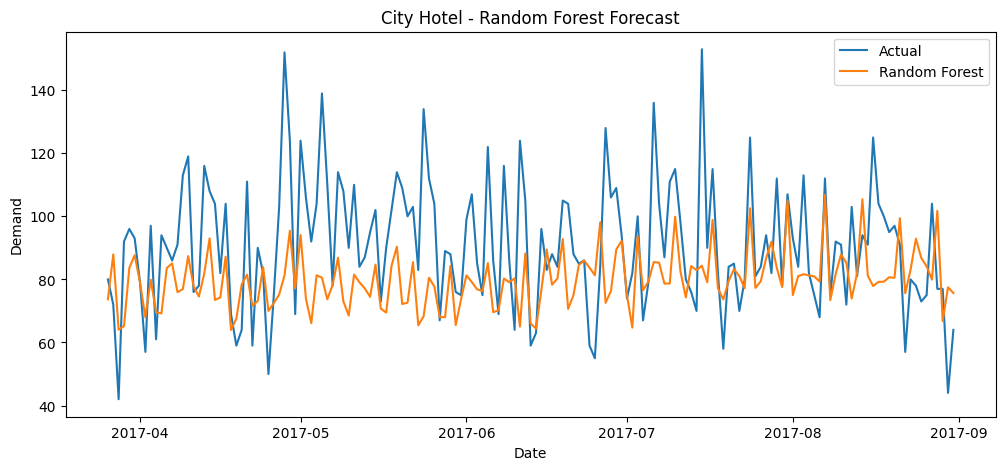

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_city.index, y_test_city, label="Actual")
plt.plot(y_test_city.index, city_rf, label="Random Forest")

plt.title("City Hotel - Random Forest Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

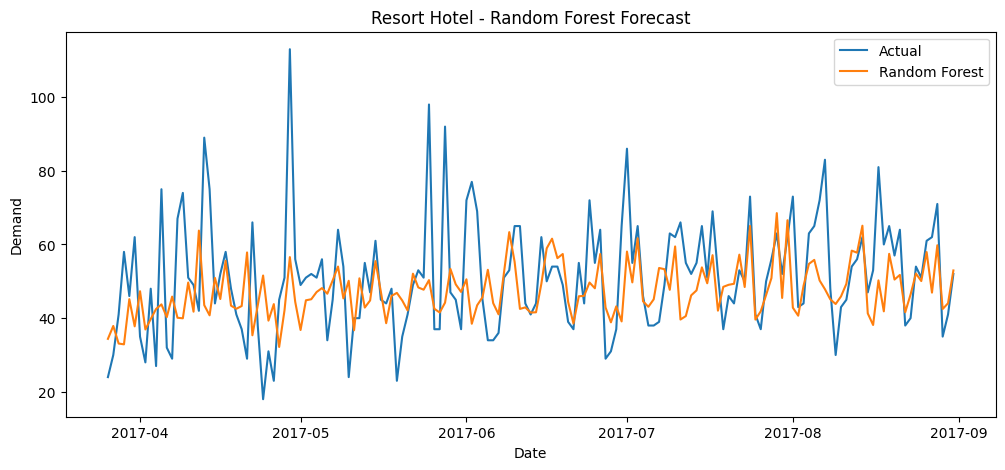

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_resort.index, y_test_resort, label="Actual")
plt.plot(y_test_resort.index, resort_rf, label="Random Forest")

plt.title("Resort Hotel - Random Forest Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

**Model Comparison**

In [37]:
def forecast_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100
    bias = np.mean(predicted - actual)

    return round(mae, 2), round(rmse, 2), round(mape, 2), round(bias, 2)

In [38]:
city_results = pd.DataFrame([
    ["Moving Average", *forecast_metrics(city_test, city_ma)],
    ["SARIMA", *forecast_metrics(city_test, city_sarima)],
    ["Random Forest", *forecast_metrics(y_test_city, city_rf)]
], columns=["Model", "MAE", "RMSE", "MAPE", "Forecast Bias"])

city_results

,Model,MAE,RMSE,MAPE,Forecast Bias
0,Moving Average,16.47,20.84,19.39,0.10
1,SARIMA,16.37,21.05,NaN,NaN
2,Random Forest,16.86,22.07,17.68,-10.89


In [39]:
resort_results = pd.DataFrame([
    ["Moving Average", *forecast_metrics(resort_test, resort_ma)],
    ["SARIMA", *forecast_metrics(resort_test, resort_sarima)],
    ["Random Forest", *forecast_metrics(y_test_resort, resort_rf)]
], columns=["Model", "MAE", "RMSE", "MAPE", "Forecast Bias"])

resort_results

,Model,MAE,RMSE,MAPE,Forecast Bias
0,Moving Average,12.73,16.54,27.03,-0.58
1,SARIMA,17.65,21.74,NaN,NaN
2,Random Forest,11.07,15.38,22.37,-3.81


In [40]:
def safe_mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mask = actual != 0

    return np.mean(
        np.abs((actual[mask] - predicted[mask]) / actual[mask])
    ) * 100

In [41]:
city_sarima_mape = safe_mape(city_test, city_sarima)
resort_sarima_mape = safe_mape(resort_test, resort_sarima)

print("City SARIMA MAPE:", round(city_sarima_mape, 2))
print("Resort SARIMA MAPE:", round(resort_sarima_mape, 2))

City SARIMA MAPE: 17.62
Resort SARIMA MAPE: 31.74


In [42]:
city_sarima_bias = np.mean(city_sarima - city_test)
resort_sarima_bias = np.mean(resort_sarima - resort_test)

print("City SARIMA Bias:", round(city_sarima_bias, 2))
print("Resort SARIMA Bias:", round(resort_sarima_bias, 2))

City SARIMA Bias: nan
Resort SARIMA Bias: nan


In [43]:
print("City SARIMA NaNs:", pd.isna(city_sarima).sum())
print("Resort SARIMA NaNs:", pd.isna(resort_sarima).sum())

City SARIMA NaNs: 0
Resort SARIMA NaNs: 0


In [44]:
print(city_sarima[:10])
print(resort_sarima[:10])

2017-03-26    74.866821
2017-03-27    88.744549
2017-03-28    68.201700
2017-03-29    70.411581
2017-03-30    82.524474
2017-03-31    88.134322
2017-04-01    70.777604
2017-04-02    76.801153
2017-04-03    89.621715
2017-04-04    69.193546
Freq: D, Name: predicted_mean, dtype: float64
2017-03-26    31.448492
2017-03-27    40.852067
2017-03-28    29.692097
2017-03-29    27.702339
2017-03-30    34.060463
2017-03-31    33.782214
2017-04-01    43.440848
2017-04-02    30.375100
2017-04-03    41.954087
2017-04-04    31.497257
Freq: D, Name: predicted_mean, dtype: float64


In [45]:
city_mask = ~np.isnan(city_sarima)

city_bias = np.mean(
    city_sarima[city_mask] - city_test.values[city_mask]
)

resort_mask = ~np.isnan(resort_sarima)

resort_bias = np.mean(
    resort_sarima[resort_mask] - resort_test.values[resort_mask]
)

print("City SARIMA Bias:", round(city_bias, 2))
print("Resort SARIMA Bias:", round(resort_bias, 2))

City SARIMA Bias: -8.18
Resort SARIMA Bias: -15.89


In [46]:
forecast_results = pd.DataFrame({
    "Hotel": [
        "City Hotel", "City Hotel", "City Hotel",
        "Resort Hotel", "Resort Hotel", "Resort Hotel"
    ],
    "Model": [
        "Moving Average", "SARIMA", "Random Forest",
        "Moving Average", "SARIMA", "Random Forest"
    ],
    "MAE": [
        16.47, 16.37, 16.86,
        12.73, 17.65, 11.07
    ],
    "RMSE": [
        20.84, 21.05, 22.07,
        16.54, 21.74, 15.38
    ],
    "MAPE": [
        19.39, 17.62, 17.68,
        27.03, 31.74, 22.37
    ],
    "Forecast_Bias": [
        0.10, -8.18, -10.89,
        -0.58, -15.89, -3.81
    ]
})

forecast_results

,Hotel,Model,MAE,RMSE,MAPE,Forecast_Bias
0,City Hotel,Moving Average,16.47,20.84,19.39,0.10
1,City Hotel,SARIMA,16.37,21.05,17.62,-8.18
2,City Hotel,Random Forest,16.86,22.07,17.68,-10.89
3,Resort Hotel,Moving Average,12.73,16.54,27.03,-0.58
4,Resort Hotel,SARIMA,17.65,21.74,31.74,-15.89
5,Resort Hotel,Random Forest,11.07,15.38,22.37,-3.81


In [47]:
forecast_results.to_csv(base_path + "forecast_model_comparison.csv", index=False)

**Actual vs Predicted**

In [49]:
city_forecast = pd.DataFrame({
    "Date": city_test.index,
    "Hotel": "City Hotel",
    "Actual_Bookings": city_test.values,
    "Moving_Average": city_ma,
    "SARIMA": city_sarima,
    "Random_Forest": city_rf
})

In [50]:
resort_forecast = pd.DataFrame({
    "Date": resort_test.index,
    "Hotel": "Resort Hotel",
    "Actual_Bookings": resort_test.values,
    "Moving_Average": resort_ma,
    "SARIMA": resort_sarima,
    "Random_Forest": resort_rf
})

In [51]:
forecast_predictions = pd.concat(
    [city_forecast, resort_forecast],
    ignore_index=True
)

In [52]:
forecast_predictions.to_csv(base_path + "forecast_predictions.csv", index=False)

In [53]:
forecast_predictions.head()

,Date,Hotel,Actual_Bookings,Moving_Average,SARIMA,Random_Forest
0,2017-03-26,City Hotel,80,75.142857,74.866821,73.725
1,2017-03-27,City Hotel,72,75.142857,88.744549,87.930
2,2017-03-28,City Hotel,42,72.857143,68.201700,64.050
3,2017-03-29,City Hotel,92,70.000000,70.411581,65.150
4,2017-03-30,City Hotel,96,73.285714,82.524474,83.630


**Future 30 Days Forecast**

In [54]:
city_future_model = SARIMAX(
    city,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

city_future_fit = city_future_model.fit(disp=False)

city_future_predictions = city_future_fit.forecast(steps=30)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [55]:
resort_future_model = SARIMAX(
    resort,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)

resort_future_fit = resort_future_model.fit(disp=False)

resort_future_predictions = resort_future_fit.forecast(steps=30)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [57]:
last_date = pd.to_datetime(daily_demand["arrival_date"].max())

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

In [58]:
city_future_df = pd.DataFrame({
    "Date": future_dates,
    "Hotel": "City Hotel",
    "Predicted_Bookings": city_future_predictions.values
})

In [59]:
resort_future_df = pd.DataFrame({
    "Date": future_dates,
    "Hotel": "Resort Hotel",
    "Predicted_Bookings": resort_future_predictions.values
})

In [60]:
future_forecast = pd.concat(
    [city_future_df, resort_future_df],
    ignore_index=True
)

In [61]:
future_forecast["Predicted_Bookings"] = (
    future_forecast["Predicted_Bookings"].clip(lower=0)
)

In [62]:
future_forecast.to_csv(
    base_path + "future_booking_forecast.csv",
    index=False
)

In [63]:
future_forecast.head()

,Date,Hotel,Predicted_Bookings
0,2017-09-01,City Hotel,80.102819
1,2017-09-02,City Hotel,75.856440
2,2017-09-03,City Hotel,79.074689
3,2017-09-04,City Hotel,90.433998
4,2017-09-05,City Hotel,71.330169


In [64]:
future_forecast.tail()

,Date,Hotel,Predicted_Bookings
55,2017-09-26,Resort Hotel,50.181780
56,2017-09-27,Resort Hotel,48.470557
57,2017-09-28,Resort Hotel,56.074792
58,2017-09-29,Resort Hotel,54.789980
59,2017-09-30,Resort Hotel,62.988532


**Actual vs Predicted**

In [66]:
predictions = pd.read_csv(base_path + "forecast_predictions.csv")

In [67]:
predictions["Predicted_Bookings"] = predictions.apply(
    lambda row: row["SARIMA"]
    if row["Hotel"] == "City Hotel"
    else row["Random_Forest"],
    axis=1
)

In [68]:
actual_vs_predicted = predictions[
    [
        "Date",
        "Hotel",
        "Actual_Bookings",
        "Predicted_Bookings"
    ]
].copy()

In [69]:
actual_vs_predicted.head()

,Date,Hotel,Actual_Bookings,Predicted_Bookings
0,2017-03-26,City Hotel,80,74.866821
1,2017-03-27,City Hotel,72,88.744549
2,2017-03-28,City Hotel,42,68.201700
3,2017-03-29,City Hotel,92,70.411581
4,2017-03-30,City Hotel,96,82.524474


In [71]:
actual_vs_predicted.to_csv(base_path + "actual_vs_predicted.csv", index=False)